# Physically Informed Neural Network for the Acoustic Wave Equation
We aim at building a function $p(x, y, x_0, y_0, t)$ which gives the value of a pressure field evolving through time, subject to an external pressure source, where the pressure wave propagates according to the acoustic wave equation. This function shouldgive the value of the pressure field at a specific spatiotemporal point, when the wave is excited by an external source centered in $(x_0, y_0)$. The acoustic wave equation is given by $$\frac{\partial^2 p}{\partial t^2} = c^2\nabla^2 p + s,$$ where $s$ is the external forcing term. The function $c$ is continuous in space but fixed in time (in the current case, it is a constant function $c=5$ everywhere, but it can be generalized to non-constant functions). 

The function can be approximated by a Neural Network, trained to optimize minimize, for any input $(x, y, x_0, y_0, t)$, the residual $$|\frac{\partial^2 p_{x, y, t}}{\partial t^2} - 5^2\nabla^2 p_{x, y, t} - s_{x, y, x_0, y_0, t}|$$, where the subcript $(x, y, t)$ denotes the evaluation of a function at those coordinates in space and time.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary

device = "mps"

We define the external source function. It is a Gaussian field centered in $(x_0, y_0)$, multiplied by a Ricker wavelet, whose peak is at $t=1$.

In [2]:
def source(x, y, t, cx=0, cy=0, sigma=.3, amplitude_g=1e2, f=1.0, amplitude_r=1.0, t0=1.0):
    dx, dy = x - cx, y - cy
    gaussian = amplitude_g * torch.exp(-(dx**2/(2*sigma**2)+dy**2/(2*sigma**2)))
    tau = t - t0
    pi2f2tau2 = (torch.pi * f)**2 * tau**2
    ricker = amplitude_r * (1.0 - 2.0 * pi2f2tau2) * torch.exp(-pi2f2tau2)
    return gaussian * ricker

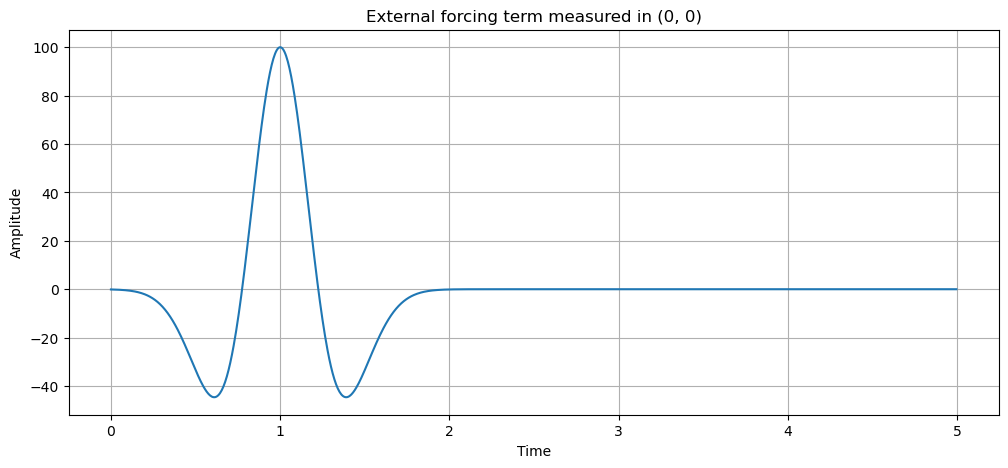

In [3]:
n_t = 1000
plt.figure(figsize=(12, 5))
plt.plot(torch.arange(0, 5, 5/n_t), source(torch.zeros(n_t), torch.zeros(n_t), torch.arange(0, 5, 5/n_t), 0, 0))
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("External forcing term measured in (0, 0)")
plt.grid()
plt.show()

We construct a Finite Difference solver which will serve as reference.

In [4]:
def run_fd_reference(c: float = 5.0, t_max: float = 5.0, n_t: int = 750, L: float = 40.0, dx: float = 0.05):
    dt = t_max / n_t
    cfl = c * dt / dx
    assert cfl < 1 / np.sqrt(2), f"CFL = {cfl:.3f} unstable, reduce dt or increase dx"
    nx = int(2 * L / dx) + 1
    x1d = np.linspace(-L, L, nx)
    X, Y = np.meshgrid(x1d, x1d, indexing="ij")
    r2 = (c * dt / dx) ** 2
    p_prev = np.zeros((nx, nx))
    p_curr = np.zeros((nx, nx))
    def idx(v): return int(round((v + L) / dx))
    rec_pts = {
        "(-1,0)": (idx(-1.0), idx(0.0)),
        "(0,0)":  (idx( 0.0), idx(0.0)),
        "(1,0)":  (idx( 1.0), idx(0.0)),
    }
    traces = {k: np.zeros(n_t) for k in rec_pts}
    t_arr  = np.linspace(0, t_max, n_t)
    for it, t in tqdm(enumerate(t_arr)):
        lap = (p_curr[2:, 1:-1] + p_curr[:-2, 1:-1] + p_curr[1:-1, 2:] + p_curr[1:-1, :-2] - 4.0 * p_curr[1:-1, 1:-1])
        src = source(torch.tensor(X), torch.tensor(Y), torch.tensor(t)).numpy()[1:-1, 1:-1]
        p_next = np.zeros_like(p_curr)
        p_next[1:-1, 1:-1] = (2.0 * p_curr[1:-1, 1:-1] - p_prev[1:-1, 1:-1] + r2 * lap+ dt ** 2 * src)
        for k, (ix, iy) in rec_pts.items():
            traces[k][it] = p_next[ix, iy]
        p_prev, p_curr = p_curr, p_next
    return t_arr, traces

t_fd, fd_seis = run_fd_reference()

0it [00:00, ?it/s]

We plot the seismograms:

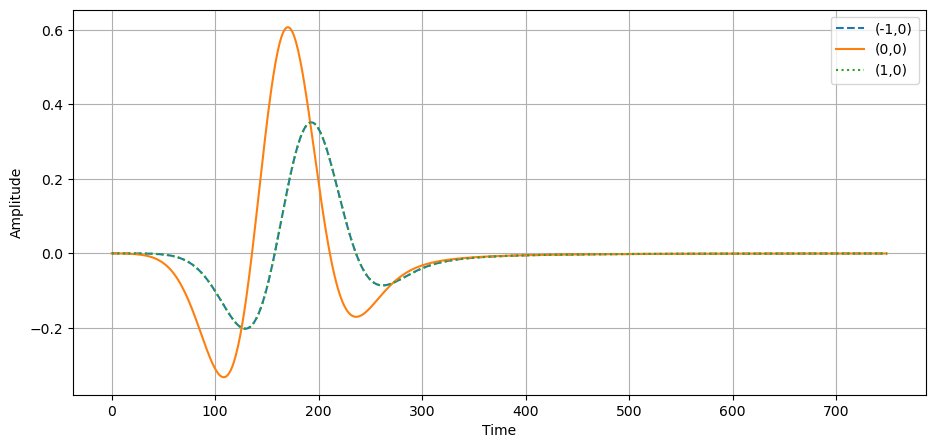

In [5]:
receiver_labels = ['(-1,0)','(0,0)','(1,0)']
plt.figure(figsize=(11, 5))
plt.plot(fd_seis['(-1,0)'], label='(-1,0)', linestyle='dashed')
plt.plot(fd_seis['(0,0)'], label='(0,0)')
plt.plot(fd_seis['(1,0)'], label='(1,0)', linestyle='dotted')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

We design a function to check specific seismograms produced by querying the model:

In [6]:
def check_seismograms(model, c_val: float = 5.0, t_max: float = 5.0, n_t: int = 500):
    c  = c_val 
    x  = torch.ones(n_t, 1, device=device)
    y  = torch.zeros(n_t, 1, device=device)
    t  = torch.linspace(0, t_max, n_t, device=device).unsqueeze(1)
 
    with torch.no_grad():
        p_neg1 = model(-x, y, torch.zeros_like(x), torch.zeros_like(y), t).squeeze().cpu().numpy()
        p_zero = model(0*x, y, torch.zeros_like(x), torch.zeros_like(y), t).squeeze().cpu().numpy()
        p_pos1 = model(x, y, torch.zeros_like(x), torch.zeros_like(y), t).squeeze().cpu().numpy()
 
    t_np = t.squeeze().cpu().numpy()
    pinn_seis = {'(-1,0)': p_neg1, '(0,0)': p_zero, '(1,0)': p_pos1}
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
 
    for ax, label in zip(axes, receiver_labels):
        ax.plot(t_np,  pinn_seis[label], label='PINN',      linewidth=1.5)
        ax.plot(t_fd,  fd_seis[label],   label='FD ref',    linewidth=1.5,
                linestyle='--', color='tomato')
        ax.set_title(f"Receiver {label}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Amplitude")
        ax.legend()
        ax.grid(True)
 
    fig.suptitle(f"Seismograms — c = {c_val}  (PINN vs Finite Difference reference)",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

We train the PINN. To do so, we sample random points $x, y, t$, alongside with random values $c$, and we compute the loss of the output produced by the PINN. $x, y$ are sampled in $[-1, 1]$, $t$ is sampled in $[0, 10]$ and $c$ is sampled in $[0.02, 2.02]$. Since we want to overfit the loss function, we purposely chose a small learning rate. Also, it is well-known that PINN's require a really long training for convergence.

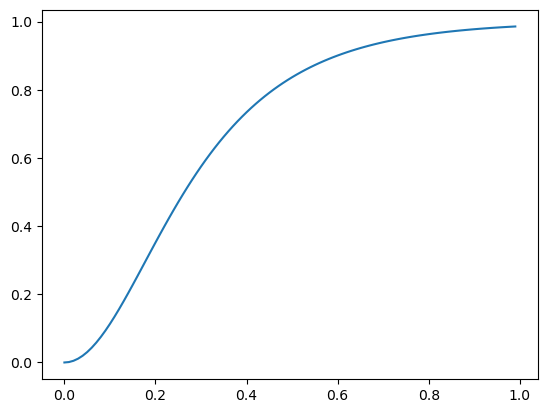

In [10]:
def g(t, alpha=1.0):
    return 1-1/torch.cosh(5*t)
plt.plot(torch.arange(0, 1, 0.01), g(torch.arange(0, 1, 0.01)))

In [11]:
class AcousticPINN(nn.Module):
    def __init__(self, n_layers=8, layer_width=32):
        super().__init__()
        self.n_layers = n_layers
        self.layer_width = layer_width
        
        self.lift = nn.Sequential(nn.Linear(5, self.layer_width), nn.Tanh())
        self.layers1 = nn.ModuleList([nn.Sequential(nn.Linear(self.layer_width, self.layer_width), nn.Tanh()) for i in range(self.n_layers)])
        self.layers2 = nn.ModuleList([nn.Sequential(nn.Linear(self.layer_width, self.layer_width), nn.Tanh()) for i in range(self.n_layers)])
        self.compress = nn.Sequential(nn.Linear(self.layer_width, self.layer_width), nn.Tanh())
        self.output = nn.Sequential(nn.Linear(self.layer_width, 1))
                                
    def forward(self, x, y, x0, y0, t):
        inits = torch.cat([x, y, x0, y0, t], dim=-1)
        o = [self.lift(inits)]
        for i in range(self.n_layers):
            o.append(self.layers1[i](o[-1]))
        p = [o[-1]]
        for i in range(self.n_layers):
            p.append(self.layers2[i](p[-1])+o[-(i+1)])            
        return self.output(self.compress(p[-1])) * g(t)
        
def loss_fn(model, x, y, x0, y0, t):
    pred = model(x, y, x0, y0, t)
    ones = torch.ones_like(pred)
    dp_dx, dp_dy, dp_dt = torch.autograd.grad(pred, [x, y, t], grad_outputs=ones, create_graph=True)
    dp_dxx = torch.autograd.grad(dp_dx, x, grad_outputs=ones, create_graph=True)[0]
    dp_dyy = torch.autograd.grad(dp_dy, y, grad_outputs=ones, create_graph=True)[0]
    dp_dtt = torch.autograd.grad(dp_dt, t, grad_outputs=ones, create_graph=True)[0]
    pde_res = dp_dtt - (5**2) * (dp_dxx + dp_dyy) - source(x, y, t, cx=x0, cy=y0)
    return (pde_res**2).mean()

In [12]:
model = AcousticPINN(n_layers=3, layer_width=64).to(device)
summary(model.cpu(), [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)])
model = model.to(device)

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64]               --
|    └─Linear: 2-1                       [-1, 1, 64]               384
|    └─Tanh: 2-2                         [-1, 1, 64]               --
├─ModuleList: 1                          []                        --
|    └─Sequential: 2-3                   [-1, 1, 64]               --
|    |    └─Linear: 3-1                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-2                    [-1, 1, 64]               --
|    └─Sequential: 2-4                   [-1, 1, 64]               --
|    |    └─Linear: 3-3                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-4                    [-1, 1, 64]               --
|    └─Sequential: 2-5                   [-1, 1, 64]               --
|    |    └─Linear: 3-5                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-6                    [-1, 1, 64]               --
├─Mod

  0%|          | 0/10000 [00:00<?, ?it/s]

Iteration 0


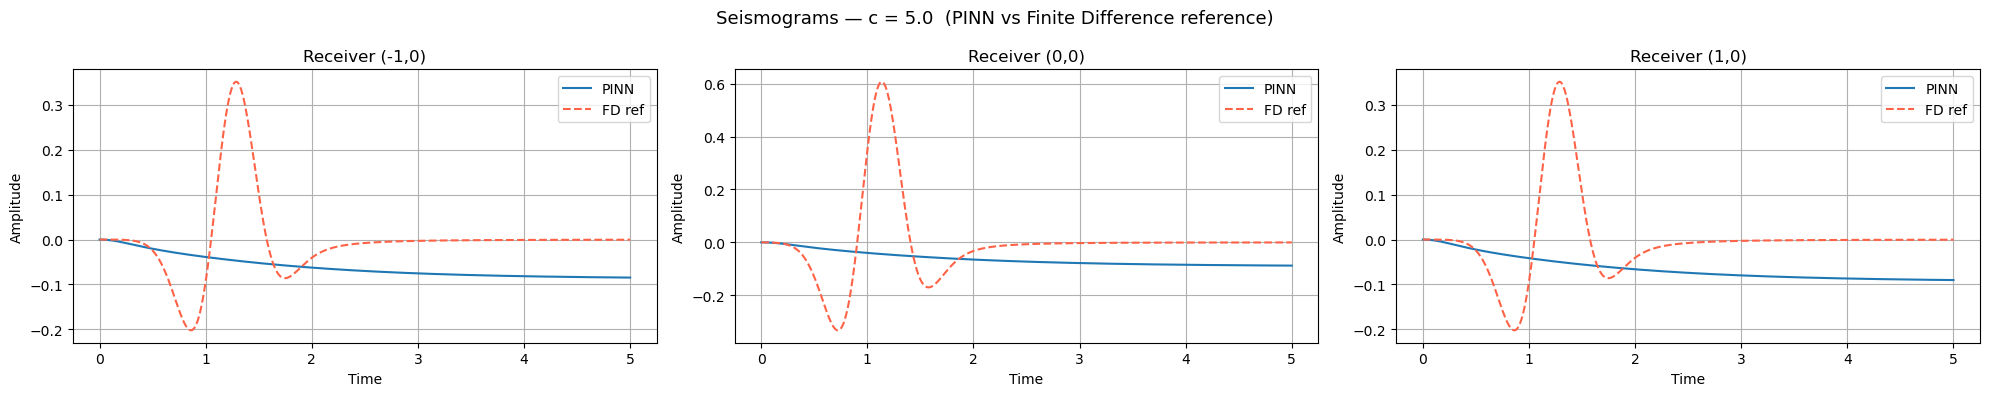

Iteration 500


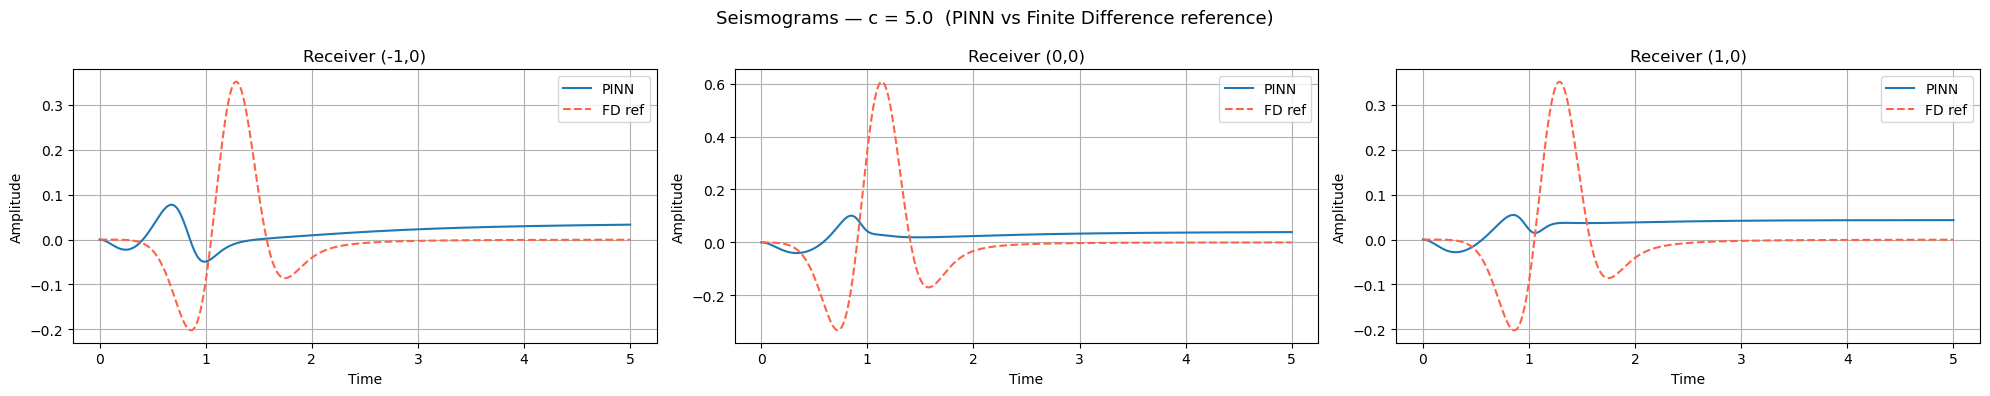

Iteration 1000


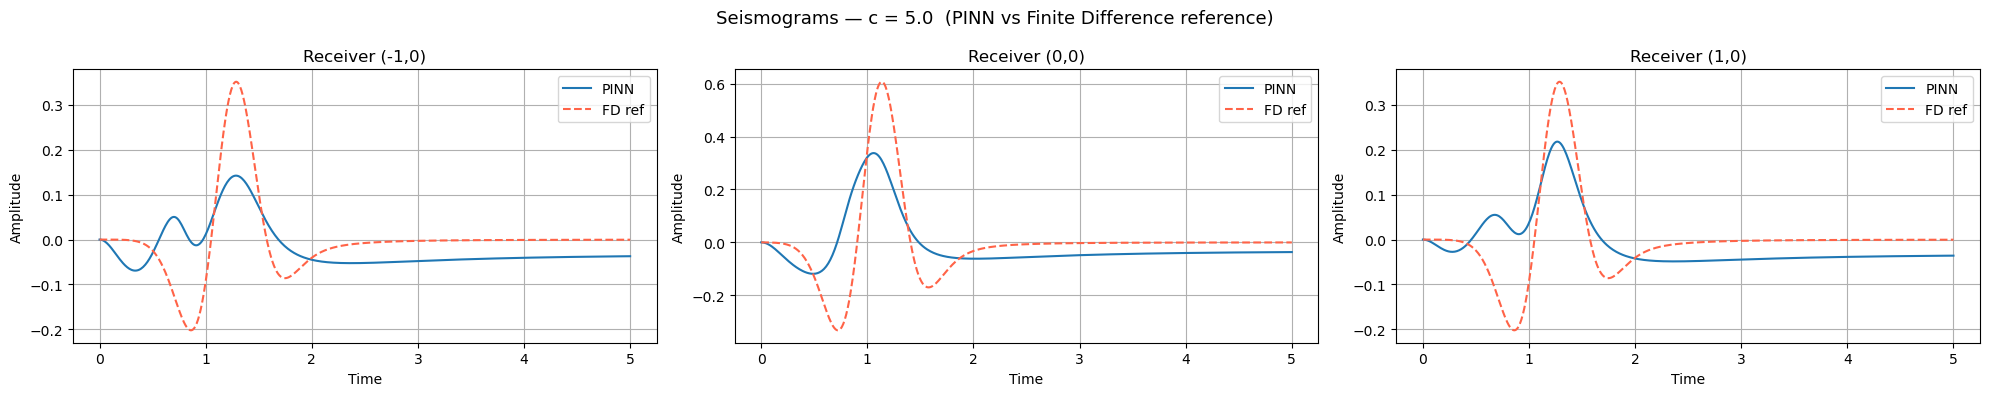

Iteration 1500


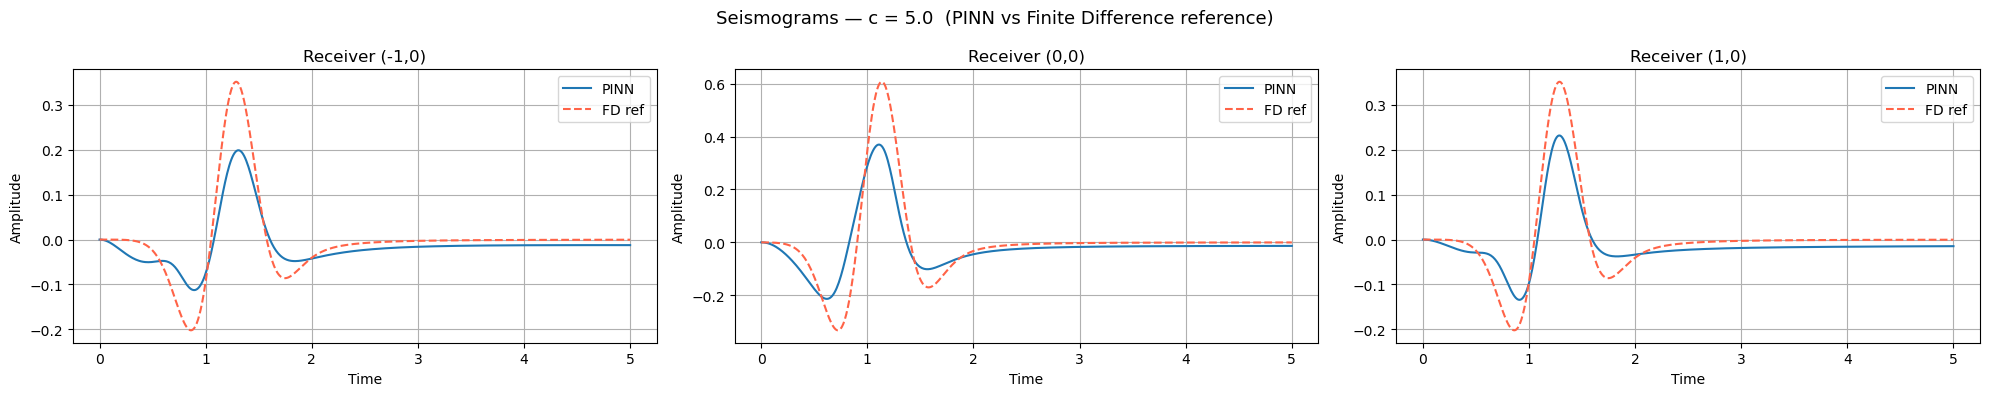

Iteration 2000


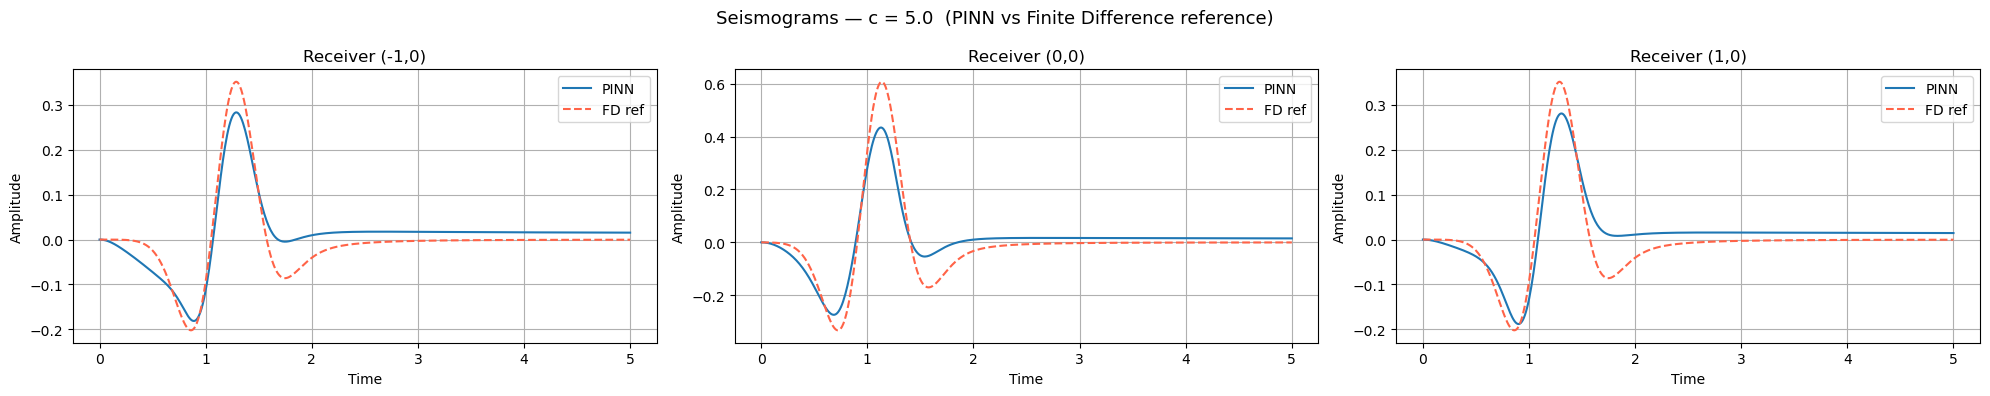

Iteration 2500


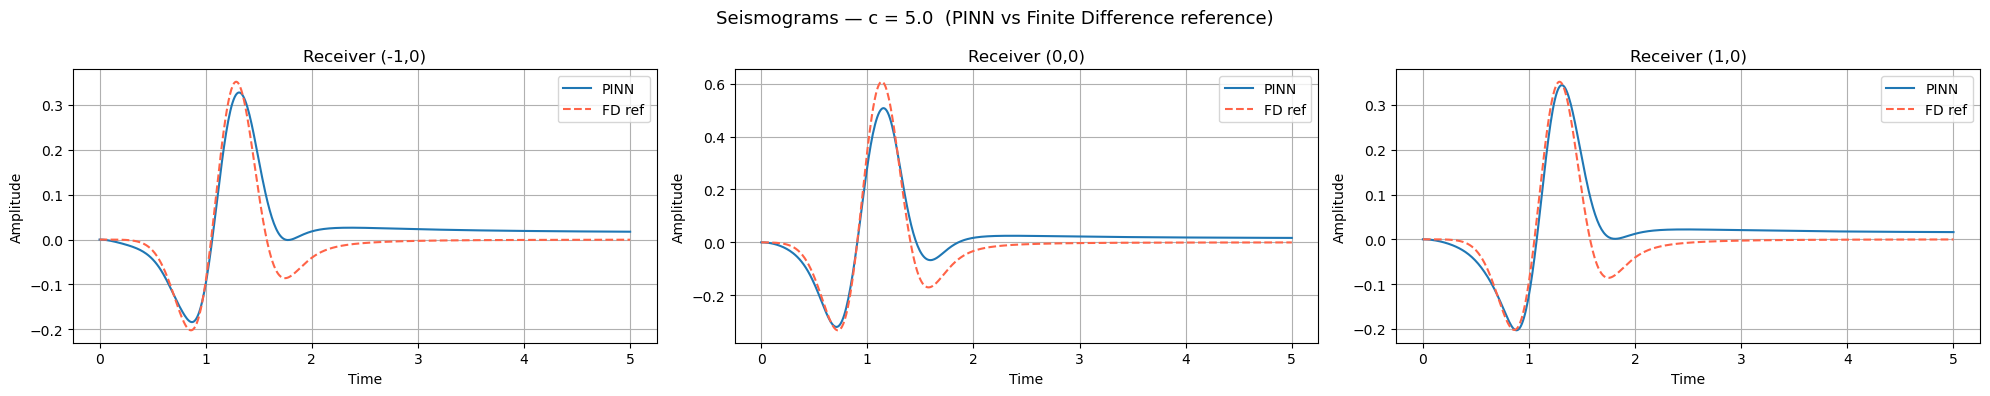

Iteration 3000


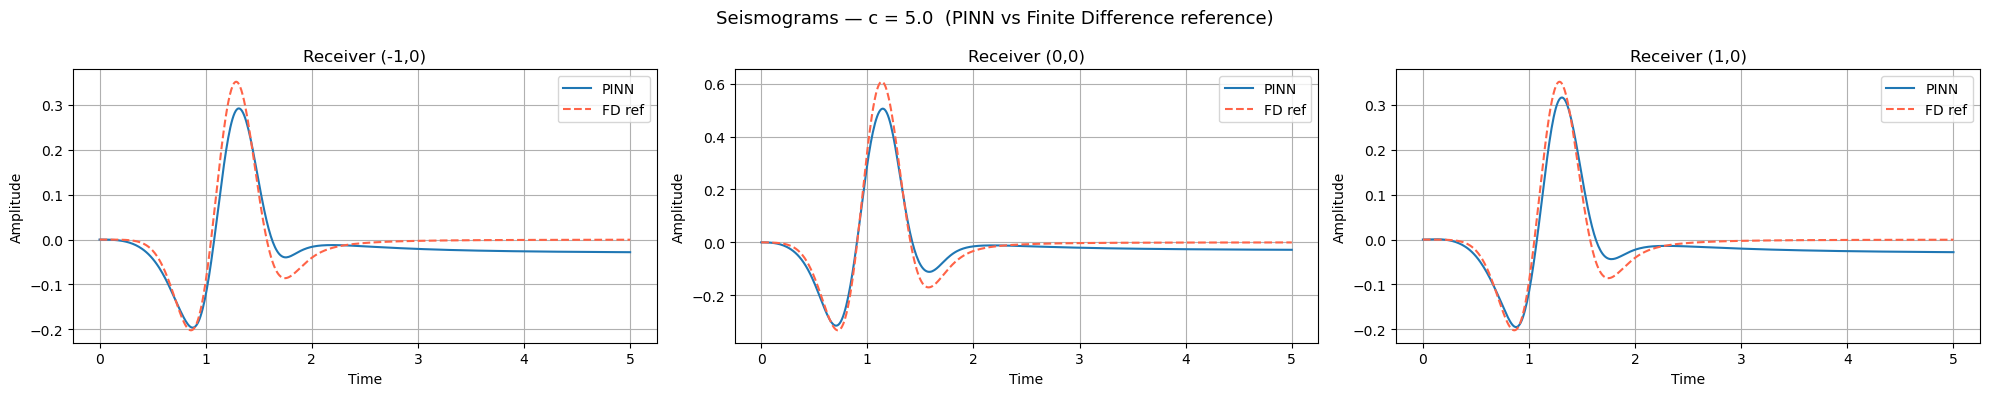

Iteration 3500


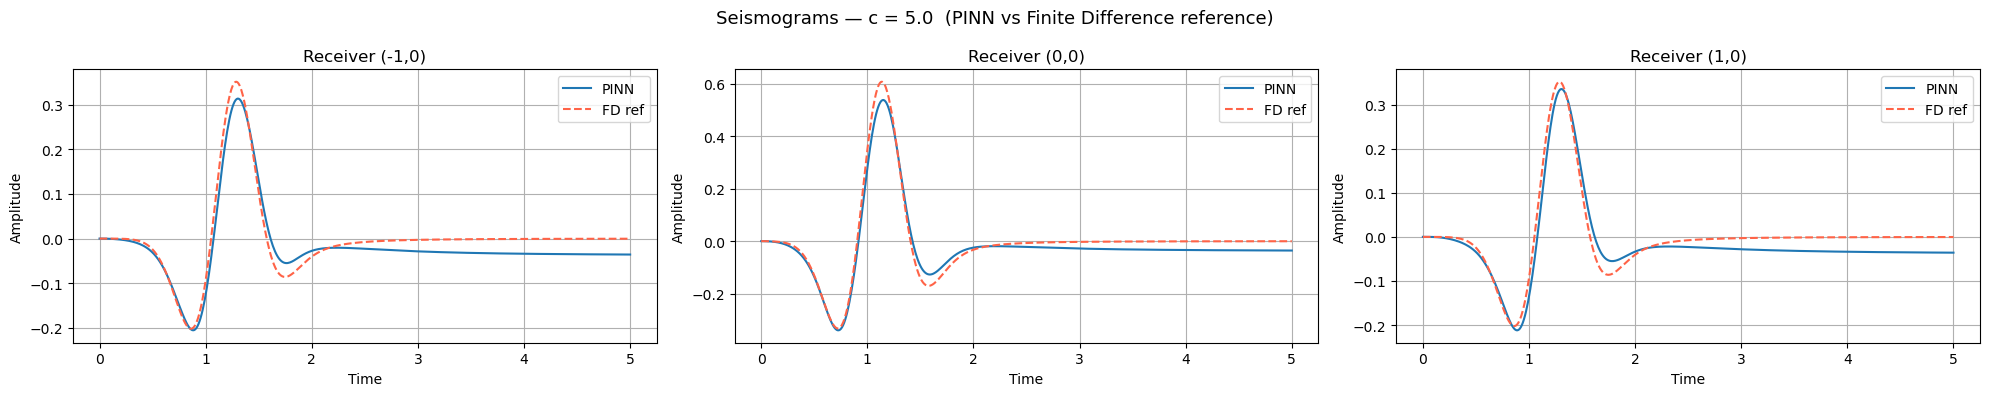

Iteration 4000


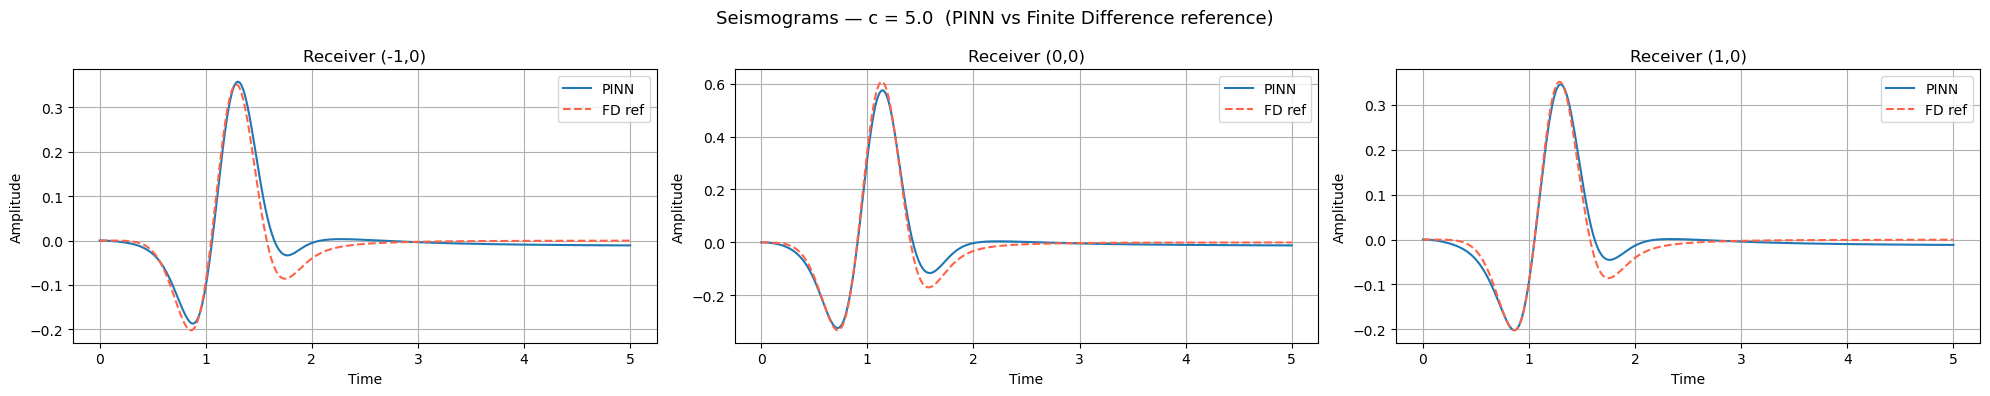

Iteration 4500


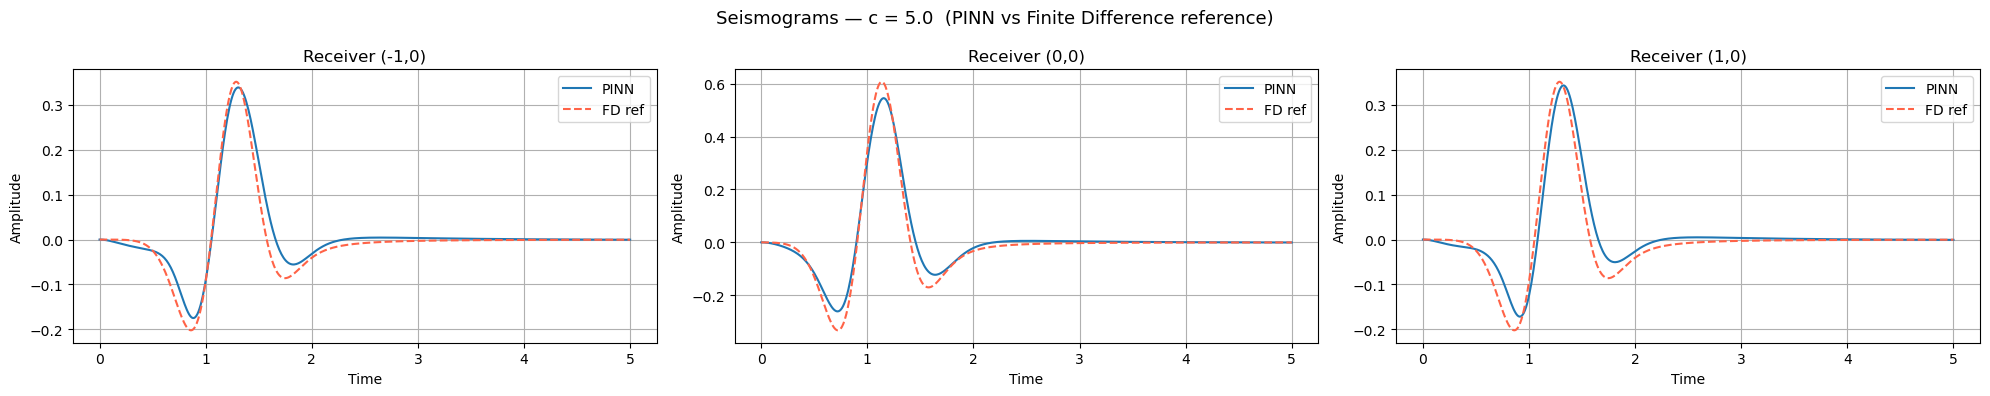

Iteration 5000


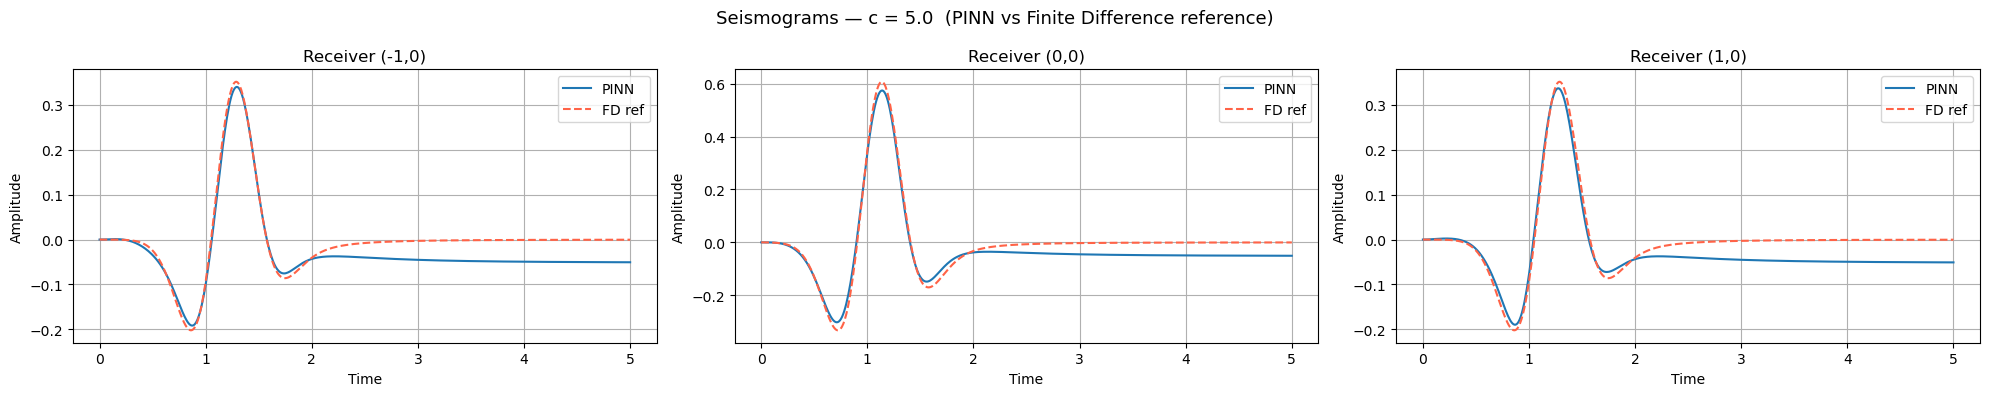

Iteration 5500


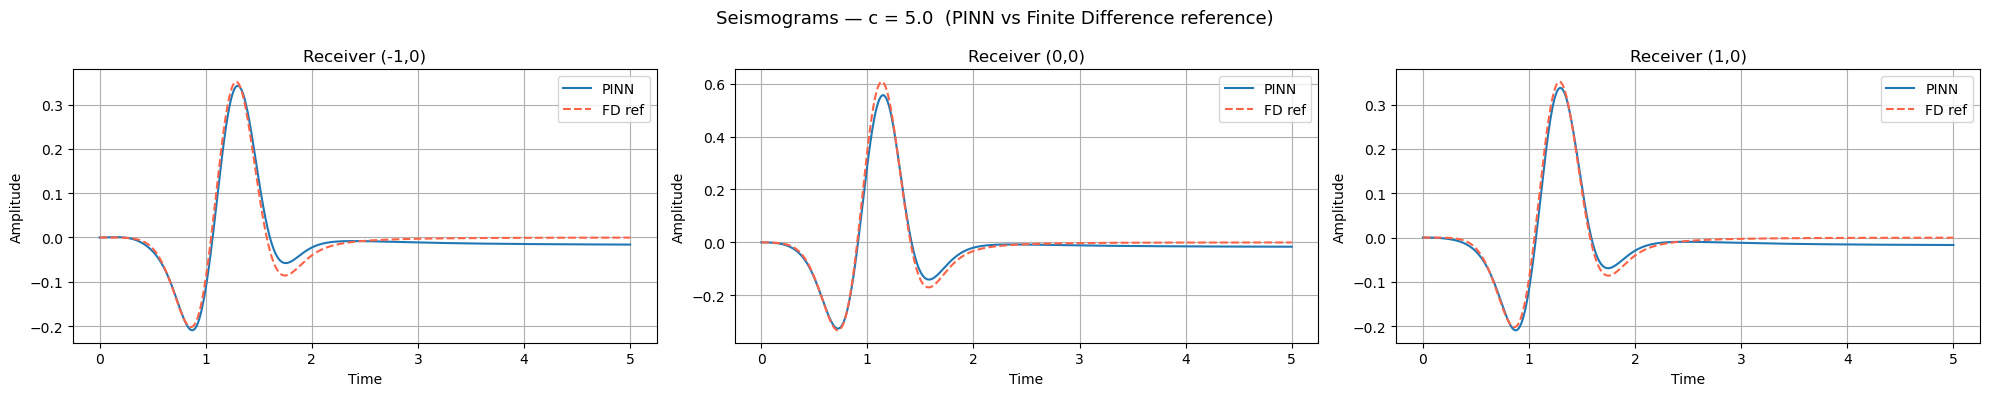

Iteration 6000


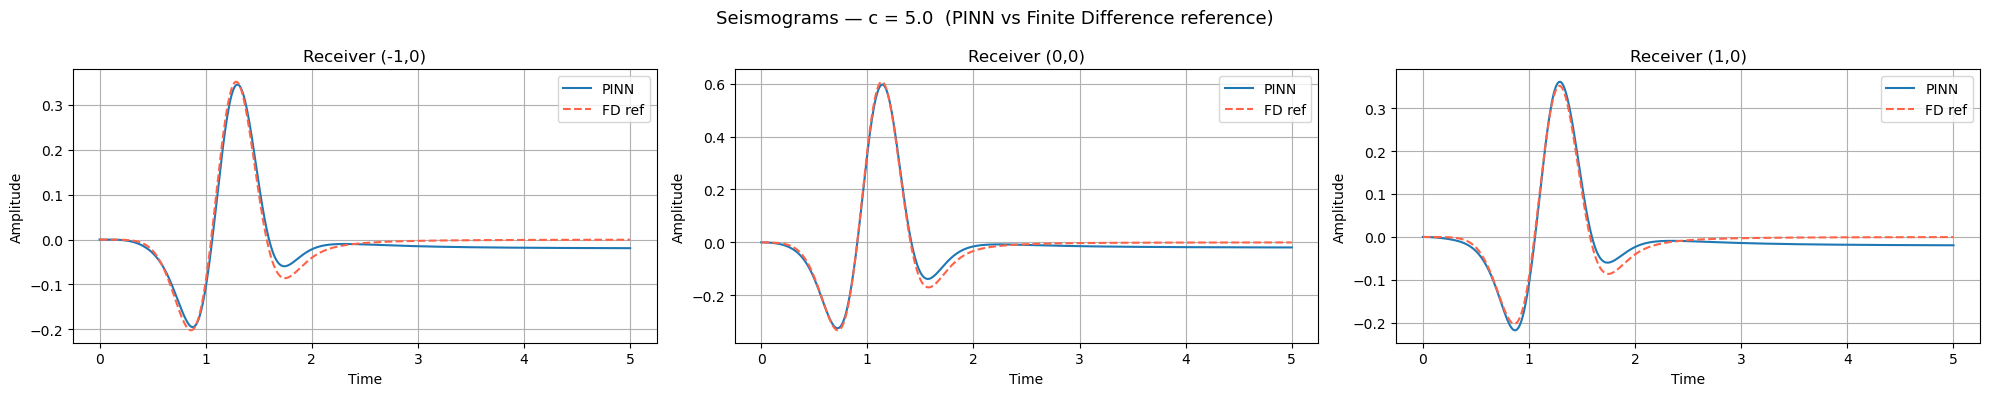

Iteration 6500


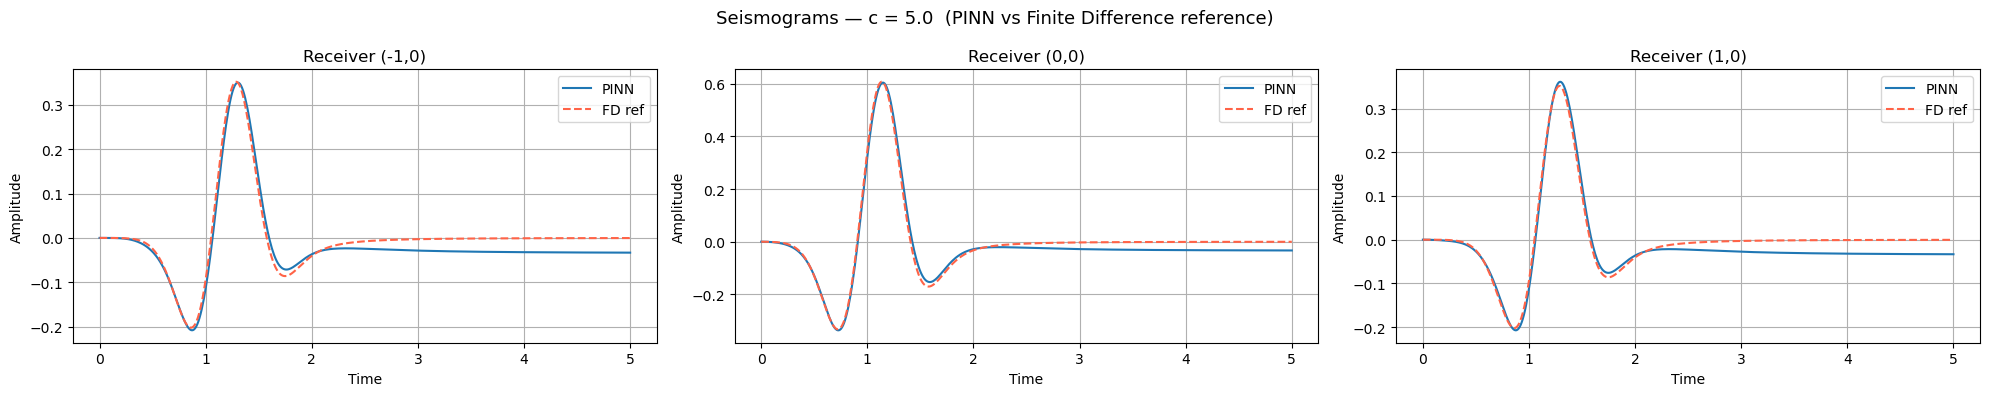

Iteration 7000


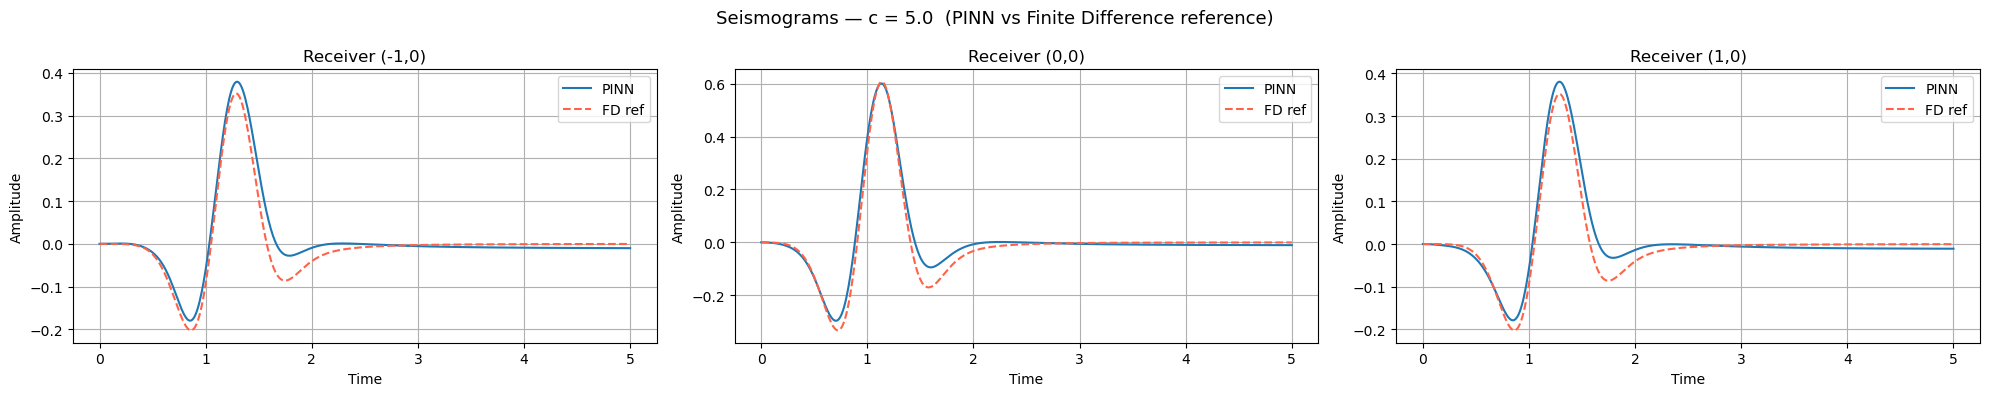

Iteration 7500


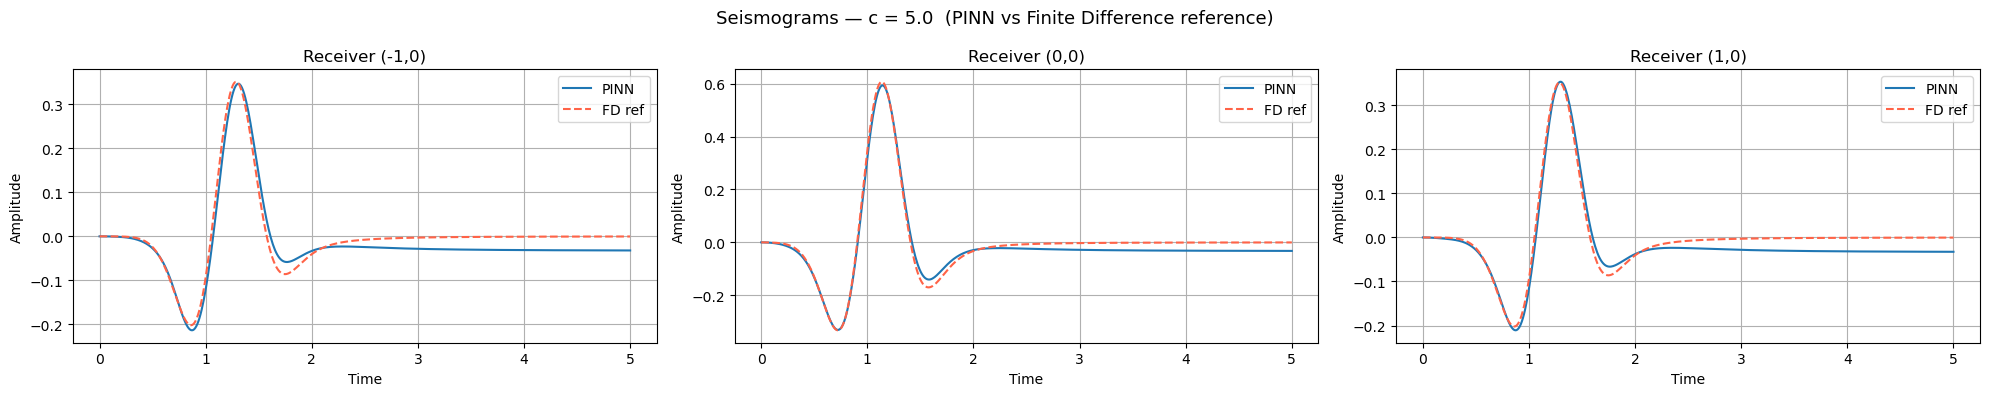

Iteration 8000


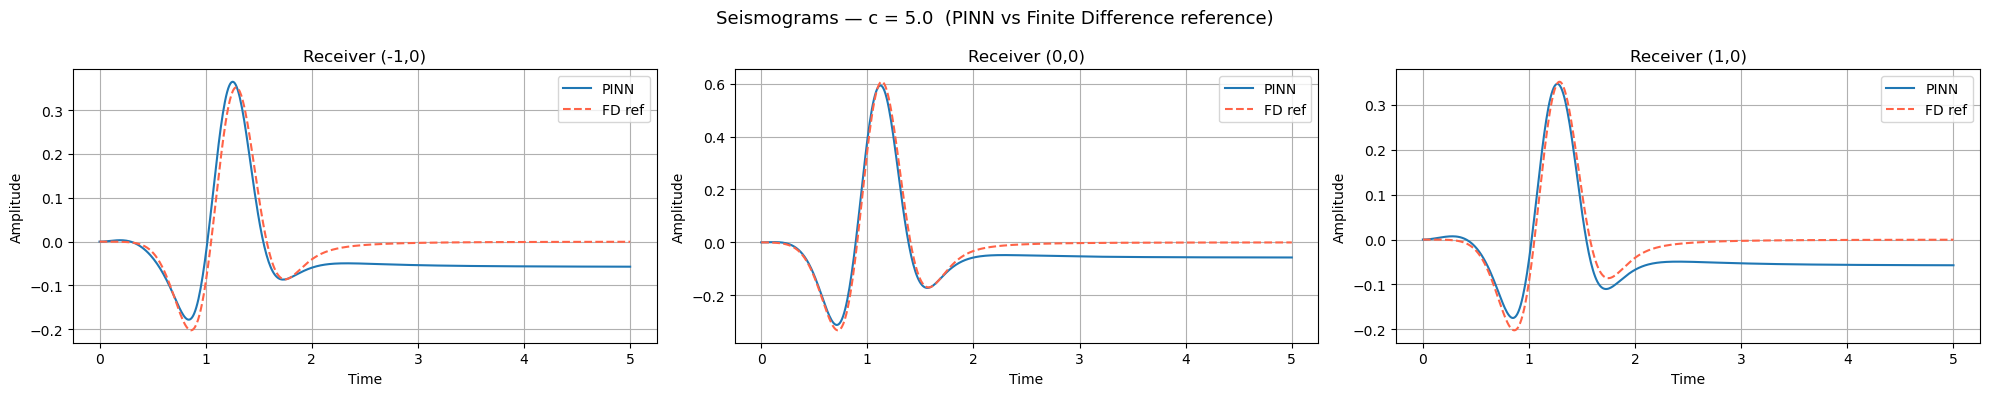

Iteration 8500


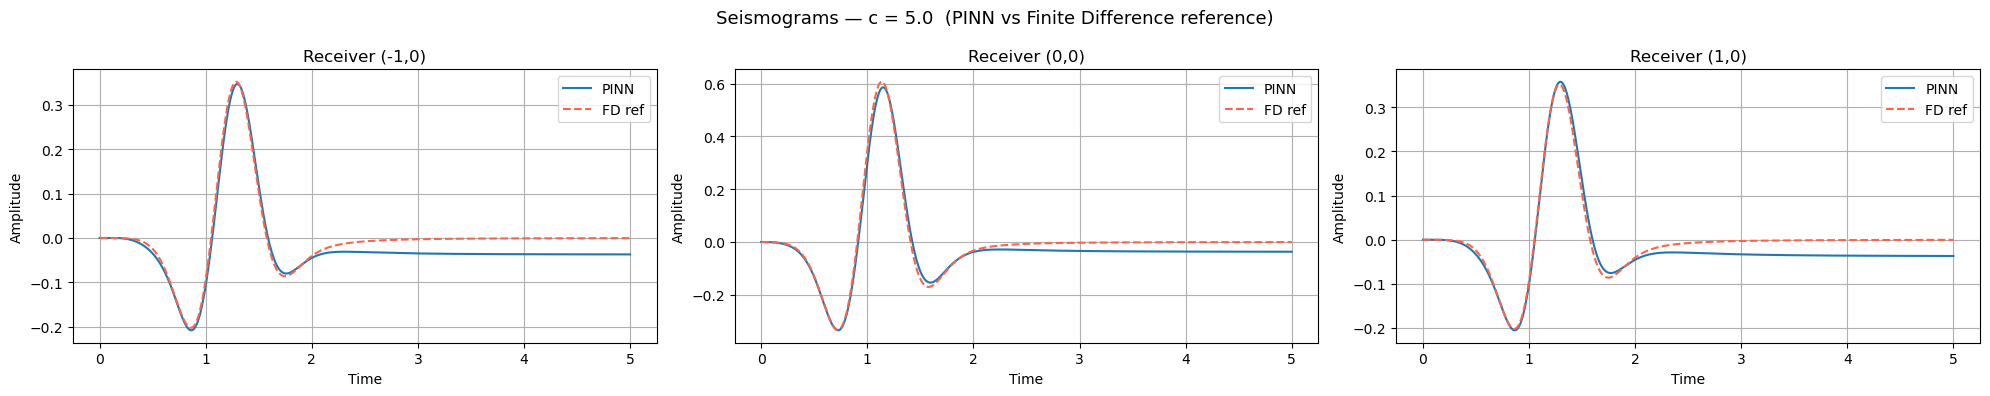

Iteration 9000


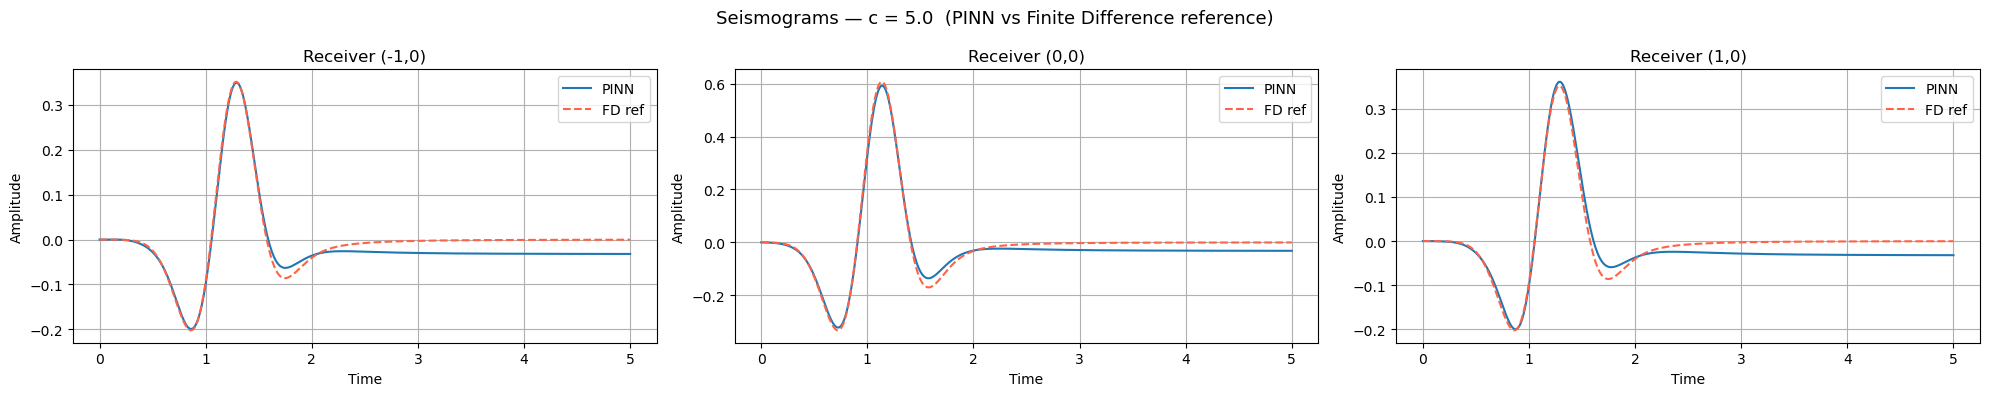

Iteration 9500


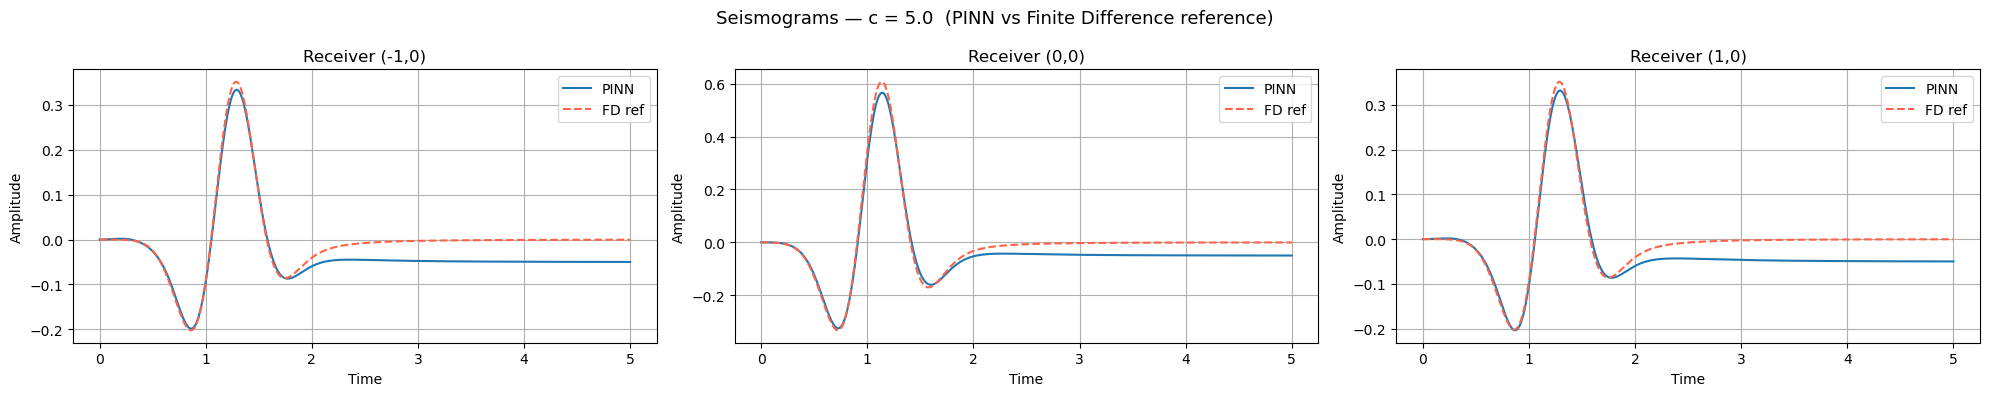

In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, threshold=5e0, patience=200)
n_points = int(1e4)

for step in (pbar:=tqdm(range(10000))):
    optimizer.zero_grad()
    x = (torch.rand(n_points, 1, requires_grad=True, device=device)-0.5)*10
    y = (torch.rand(n_points, 1, requires_grad=True, device=device)-0.5)*10
    x0 = (torch.rand(n_points, 1, requires_grad=True, device=device)-0.5)*5
    y0 = (torch.rand(n_points, 1, requires_grad=True, device=device)-0.5)*5
    t = (torch.rand(n_points, 1, requires_grad=True, device=device))*15

    loss_pde = loss_fn(model, x, y, x0, y0, t)

    pbar.set_description(f"Loss PDE: {loss_pde.item():.5e}")#, l_r: {scheduler.get_last_lr()[-1]:.3e}")
    loss_pde.backward()
    optimizer.step()
    # scheduler.step(loss_pde)
    if step%500 == 0:
        print(f"Iteration {step}")
        check_seismograms(model)
torch.save(model,"model.pt")